In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import pandas as pd
import dask.dataframe as dd
from pandas import DataFrame
import re
from numpy import savetxt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import sklearn.metrics as metrics
import sklearn
from sklearn import linear_model
from sklearn import decomposition
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from dateutil import parser

from statsmodels.tools import add_constant
from statsmodels.api import Logit
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
#import pingouin as pgn
import pingouin as pg
from pingouin import kruskal
import pylab as py
import scikit_posthocs as sp
from scipy.stats import chi2
from scipy.stats import t, shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf
#from functions import plot_sortie_acf
from statsmodels.tsa.statespace.sarimax import *
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy_indexed as npi
plt.style.use('seaborn-whitegrid')
from statsmodels.tsa.stattools import adfuller
from numpy import log

import warnings
warnings.simplefilter("ignore")

C:\Users\zobir\anaconda3\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.4.0, the latest is 0.5.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
# eCO2mix_RTE_energie_M
# calcul_DJU_10_05_2022_a => g + 1
# https://opendata.reseaux-energies.fr/explore/dataset/equilibre-national-mensuel-prod-conso-brute/export/?sort=mois&dataChart=eyJxdWVyaWVzIjpbeyJjaGFydHMiOlt7InR5cGUiOiJhcmVhIiwiZnVuYyI6IlNVTSIsInlBeGlzIjoicHJvZHVjdGlvbl90b3RhbGUiLCJjb2xvciI6IiM3QTlBQUQiLCJzY2llbnRpZmljRGlzcGxheSI6dHJ1ZX0seyJ0eXBlIjoibGluZSIsImZ1bmMiOiJTVU0iLCJ5QXhpcyI6ImNvbnNvbW1hdGlvbl9icnV0ZSIsImNvbG9yIjoiI0U4NTI1MiIsInNjaWVudGlmaWNEaXNwbGF5Ijp0cnVlfV0sInhBeGlzIjoibW9pcyIsIm1heHBvaW50cyI6IiIsInRpbWVzY2FsZSI6Im1vbnRoIiwic29ydCI6IiIsImNvbmZpZyI6eyJkYXRhc2V0IjoiZXF1aWxpYnJlLW5hdGlvbmFsLW1lbnN1ZWwtcHJvZC1jb25zby1icnV0ZSIsIm9wdGlvbnMiOnsic29ydCI6Im1vaXMifX19XSwidGltZXNjYWxlIjoiIiwic2luZ2xlQXhpcyI6dHJ1ZSwiZGlzcGxheUxlZ2VuZCI6dHJ1ZSwiYWxpZ25Nb250aCI6dHJ1ZX0%3D
# equilibre-national-mensuel-prod-conso-brute

repertoire = "C:\\Users\zobir\\OC_projets\\P9_Predisez_la_demande_en_electricite\\"
rep_data = "C:\\Users\\zobir\\OC_projets\\P9_Predisez_la_demande_en_electricite\Data\\"  # C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\Data

df_consommation = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\conso.xlsx')
df_dju = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\DJU.xlsx', skiprows=11)

df_dju_2 = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\DJU_meteo_chauf_ge.xlsx', skiprows=11)
df_dju_2a = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\Data\calcul_DJU_10_05_2022_a.xlsx', skiprows=11)
df_dju_2b = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\Data\calcul_DJU_10_05_2022_b.xlsx', skiprows=11)
df_dju_2c = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\Data\calcul_DJU_10_05_2022_c.xlsx', skiprows=11)
df_dju_2d = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\Data\calcul_DJU_10_05_2022_d.xlsx', skiprows=11)
df_dju_2e = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\Data\calcul_DJU_10_05_2022_e.xlsx', skiprows=11)
df_dju_2f = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\Data\calcul_DJU_10_05_2022_f.xlsx', skiprows=11)
df_dju_2g = pd.read_excel (r'C:\Users\zobir\OC_projets\P9_Predisez_la_demande_en_electricite\Data\calcul_DJU_10_05_2022_g.xlsx', skiprows=11)


df_consommation_2 = pd.read_csv('equilibre-national-mensuel-prod-conso-brute.csv', sep = ';')
df_consommation_21 =  df_consommation_2[['Mois','Consommation brute (GWh)']]

# Correction des données de consommation mensuelles

## Données mensuelles de consommation totale d'électricité en énergie

In [3]:
df_consommation_2

,Mois,Production totale (GWh),Pompage (GWh),Solde échanges physiques (GWh),Consommation brute (GWh)
0,2014-03,48291.0,651.0,4535.0,43104.0
1,2014-06,39366.0,632.0,6126.0,32609.0
2,2014-10,41312.0,705.0,4306.0,36301.0
3,2014-11,47114.0,710.0,5788.0,40617.0
4,2007-01,53539.0,759.0,4798.0,47982.0
...,...,...,...,...,...
177,2021-09,38503.0,389.0,5765.0,32349.0
178,2021-01,55440.0,491.0,1947.0,53003.0
179,2021-12,48283.0,806.0,-1964.0,49442.0
180,2022-01,52107.0,691.0,-1011.0,52426.0


In [4]:
df_consommation_20 =  df_consommation_21[['Mois','Consommation brute (GWh)']]
df_consommation_20['Mois']=pd.to_datetime(df_consommation_20["Mois"])
#df_consommation_20=df_consommation_20.loc[(datetime.strptime('2008-12-01', '%Y-%m-%d')< df_consommation_20['Mois']) & (df_consommation_20['Mois']<datetime.strptime('2019-10-01', '%Y-%m-%d')),:]
df_consommation_20=df_consommation_20.loc[(datetime.strptime('2008-12-01', '%Y-%m-%d')< df_consommation_20['Mois']) & (df_consommation_20['Mois']<datetime.strptime('2020-01-01', '%Y-%m-%d')),:]

df_consommation_20=df_consommation_20.rename(columns={'Consommation brute (GWh)': 'Consommation'})

#df_consommation_20=df_consommation_20.loc[(datetime.strptime('2008-12-01', '%Y-%m-%d')< df_consommation_20['Mois']) & (df_consommation_20['Mois']<datetime.strptime('2019-10-01', '%Y-%m-%d')),:]
df_consommation_20=df_consommation_20.loc[(datetime.strptime('2008-12-01', '%Y-%m-%d')< df_consommation_20['Mois']) & (df_consommation_20['Mois']<datetime.strptime('2020-01-01', '%Y-%m-%d')),:]

df_consommation_20 = df_consommation_20.set_index('Mois')
df_consommation_20

,Consommation
Mois,
2014-03-01,43104.0
2014-06-01,32609.0
2014-10-01,36301.0
2014-11-01,40617.0
2013-02-01,49639.0
...,...
2019-01-01,54117.0
2019-03-01,43146.0
2019-09-01,32214.0


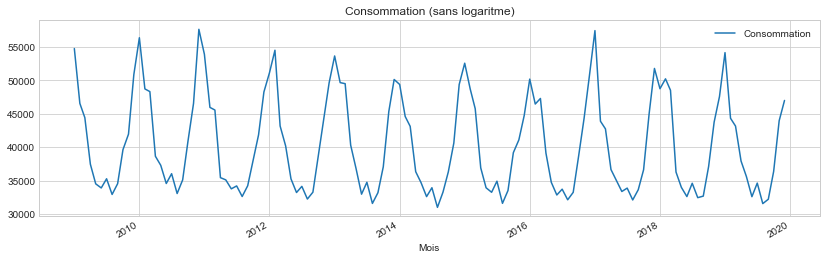

In [5]:
df_consommation_20.plot(y="Consommation", figsize=(14,4))
plt.title("Consommation (sans logaritme)")
plt.savefig('Consommation (sans logaritme)')

### Logarithme de la série Consommation

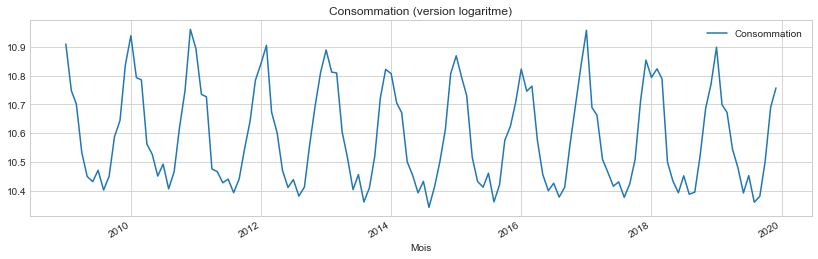

In [6]:
np.log(df_consommation_20).plot(y="Consommation", figsize=(14,4))
plt.title("Consommation (version logaritme)")
plt.savefig('Consommation (version logaritme)')

## Degrés jours unifiés (DJU)

Le degré jour est une valeur représentative de l’écart entre la température d’une journée donnée et un seuil de température préétabli (18 °C dans le cas des DJU ou Degré Jour Unifié). Sommés sur une période, ils permettent de calculer les besoins de chauffage et de climatisation d’un bâtiment.

Les données DJU sont données par régions et doivent être assemblées afin d'en extraire la moyenne nationale utilisée dans cette étude.

<img src="regions_fr.PNG"/>

In [7]:
print("Exemple DJU région grand Est:")
df_dju_2

Exemple DJU région grand Est:


,Unnamed: 0,JAN,FÉV,MAR,AVR,MAI,JUN,JUI,AOÛ,SEP,OCT,NOV,DÉC,Total
0,2021,495.4,368.9,369.8,348.5,231.1,15.7,0.0,0.0,0.0,0.0,0.0,0.0,1829.4
1,2020,411.7,325.7,350.2,204.9,168.9,68.1,39.8,16.0,80.0,210.5,318.2,407.7,2601.4
2,2019,484.5,368.9,323.6,250.0,209.5,41.5,25.9,29.1,104.6,192.5,364.8,398.0,2792.6
3,2018,379.1,491.2,400.9,184.0,96.7,38.6,1.1,27.2,112.2,215.1,355.8,411.1,2712.7
4,2017,567.3,347.7,300.3,316.5,128.3,33.2,27.3,41.7,134.9,456.9,379.5,432.7,3166.0
5,2016,445.5,380.5,398.4,283.7,141.1,48.1,24.4,29.5,62.3,260.0,360.2,502.8,2936.1
6,2015,482.7,435.6,373.5,260.0,185.8,60.7,37.6,25.6,147.6,250.7,270.1,326.5,2856.2
7,2014,393.5,352.0,340.0,218.5,166.7,65.2,20.4,72.9,89.0,168.3,294.0,448.7,2628.9
8,2013,500.6,482.4,461.6,293.0,215.8,92.1,12.3,45.5,112.0,177.0,368.1,437.2,3197.4
9,2012,430.9,531.8,313.3,294.1,128.4,86.4,53.6,21.4,147.9,239.1,360.0,422.5,3029.1


In [8]:
print("Concatenation des données et rennomage des colonnes:")

df_dju_200 = df_dju_2.append(df_dju_2a)
df_dju_200 = df_dju_200.append(df_dju_2b)
df_dju_200 = df_dju_200.append(df_dju_2c)
df_dju_200 = df_dju_200.append(df_dju_2d)
df_dju_200 = df_dju_200.append(df_dju_2e)
df_dju_200 = df_dju_200.append(df_dju_2f)
df_dju_200 = df_dju_200.append(df_dju_2g)

del df_dju_200["Total"]
df_dju_200. rename(columns = {'Unnamed: 0':'Annee', 'JAN':'01', 'FÉV':'02', 'MAR':'03', 'AVR':'04', 'MAI':'05', 'JUN':'06', 'JUI':'07', 'AOÛ':'08', 'SEP':'09', 'OCT':'10','NOV':'11', 'DÉC':'12'}, inplace = True)

df_dju_200

Concatenation des données et rennomage des colonnes:


,Annee,01,02,03,04,05,06,07,08,09,10,11,12
0,2021,495.4,368.9,369.8,348.5,231.1,15.7,0.0,0.0,0.0,0.0,0.0,0.0
1,2020,411.7,325.7,350.2,204.9,168.9,68.1,39.8,16.0,80.0,210.5,318.2,407.7
2,2019,484.5,368.9,323.6,250.0,209.5,41.5,25.9,29.1,104.6,192.5,364.8,398.0
3,2018,379.1,491.2,400.9,184.0,96.7,38.6,1.1,27.2,112.2,215.1,355.8,411.1
4,2017,567.3,347.7,300.3,316.5,128.3,33.2,27.3,41.7,134.9,456.9,379.5,432.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,2013,500.6,482.4,461.6,293.0,215.8,92.1,12.3,45.5,112.0,177.0,368.1,437.2
9,2012,430.9,531.8,313.3,294.1,128.4,86.4,53.6,21.4,147.9,239.1,360.0,422.5
10,2011,448.3,390.7,340.5,174.4,140.5,67.5,72.8,50.1,82.5,226.1,328.1,395.9
11,2010,581.4,442.7,376.9,274.5,218.1,62.7,21.7,55.2,142.5,250.1,362.1,601.9


In [9]:
print("Calcul des moyennes:")

df_dju_200_mean = df_dju_200.groupby('Annee', as_index=False).mean()
df_dju_200_mean

Calcul des moyennes:


,Annee,01,02,03,04,05,06,07,08,09,10,11,12
0,2009,468.0375,363.7250,315.3750,191.2125,102.6375,49.2875,14.3375,14.1250,53.8500,162.0000,231.7625,406.0500
1,2010,491.3750,382.8625,323.9500,213.8250,164.0000,44.9375,9.1000,27.4750,79.3750,180.8625,306.6125,489.4500
2,2011,399.9500,319.0000,291.8125,135.2500,89.3750,52.4125,40.5250,24.7750,39.1750,145.7625,232.9375,330.5250
3,2012,369.3250,454.9375,257.9750,243.4375,110.5250,50.3000,29.5750,10.9000,77.1750,156.2250,281.6250,360.1375
4,2013,417.2375,403.9375,361.7625,235.4000,179.4875,65.1750,8.5250,17.3000,57.0250,109.6625,299.0375,361.6625
5,2014,337.4250,300.7750,280.2750,172.0500,128.7625,37.8375,12.5375,35.8250,39.3750,97.6500,222.7125,366.0875
6,2015,394.4250,372.5000,298.4375,191.4750,119.3750,37.2125,18.5750,15.7250,89.1875,178.3875,214.9250,275.4625
7,2016,359.6875,320.4000,328.7375,223.0500,113.8875,39.2125,16.0625,13.4875,30.5000,177.2000,282.5500,383.8125
8,2017,463.0250,287.8500,242.1875,229.0875,96.2125,22.4250,13.3625,22.4250,82.5250,184.3250,301.0000,383.2500
9,2018,314.1250,408.9875,332.9500,155.3375,90.8000,26.0000,1.6750,13.9875,50.9125,143.2625,273.5375,326.0250


In [10]:
print("Suppression de la ligne 2021 qui contient des données manquantes:")
df_dju_200_mean.drop([12], 0, inplace=True)
df_dju_200_mean = round(df_dju_200_mean, 1)
df_dju_200_mean

Suppression de la ligne 2021 qui contient des données manquantes:


,Annee,01,02,03,04,05,06,07,08,09,10,11,12
0,2009,468.0,363.7,315.4,191.2,102.6,49.3,14.3,14.1,53.8,162.0,231.8,406.0
1,2010,491.4,382.9,324.0,213.8,164.0,44.9,9.1,27.5,79.4,180.9,306.6,489.4
2,2011,400.0,319.0,291.8,135.2,89.4,52.4,40.5,24.8,39.2,145.8,232.9,330.5
3,2012,369.3,454.9,258.0,243.4,110.5,50.3,29.6,10.9,77.2,156.2,281.6,360.1
4,2013,417.2,403.9,361.8,235.4,179.5,65.2,8.5,17.3,57.0,109.7,299.0,361.7
5,2014,337.4,300.8,280.3,172.0,128.8,37.8,12.5,35.8,39.4,97.6,222.7,366.1
6,2015,394.4,372.5,298.4,191.5,119.4,37.2,18.6,15.7,89.2,178.4,214.9,275.5
7,2016,359.7,320.4,328.7,223.0,113.9,39.2,16.1,13.5,30.5,177.2,282.5,383.8
8,2017,463.0,287.8,242.2,229.1,96.2,22.4,13.4,22.4,82.5,184.3,301.0,383.3
9,2018,314.1,409.0,333.0,155.3,90.8,26.0,1.7,14.0,50.9,143.3,273.5,326.0


In [11]:
print("Mise en forme du Dataframe:")

#df_dju_21 = pd.melt(df_dju_200_mean, id_vars=["Annee"], var_name="Mois", value_name = "Consommation")
df_dju_21 = pd.melt(df_dju_200_mean, id_vars=["Annee"], var_name="Mois", value_name = "DJU")

df_dju_21['Mois'] = df_dju_21.Annee.map(str) + "-" + df_dju_21.Mois + "-01"
df_dju_21 = df_dju_21.drop('Annee', axis=1)
df_dju_21["Mois"] = pd.to_datetime(df_dju_21.Mois, format="%Y-%m-%d")

df_dju_21=df_dju_21.loc[(datetime.strptime('2008-12-01', '%Y-%m-%d')< df_dju_21['Mois']) & (df_dju_21['Mois']<datetime.strptime('2020-10-01', '%Y-%m-%d')),:]

df_dju_21 = df_dju_21.sort_values("Mois")
df_dju_21 = df_dju_21.set_index("Mois")

df_dju_21

Mise en forme du Dataframe:


,DJU
Mois,
2009-01-01,468.0
2009-02-01,363.7
2009-03-01,315.4
2009-04-01,191.2
2009-05-01,102.6
...,...
2020-05-01,96.0
2020-06-01,45.5
2020-07-01,19.3


In [12]:
df_conso = pd.merge(df_consommation_20, df_dju_21, on="Mois")
df_conso

,Consommation,DJU
Mois,,
2014-03-01,43104.0,280.3
2014-06-01,32609.0,37.8
2014-10-01,36301.0,97.6
2014-11-01,40617.0,222.7
2013-02-01,49639.0,403.9
...,...,...
2019-01-01,54117.0,416.3
2019-03-01,43146.0,266.0
2019-09-01,32214.0,52.0


In [13]:
df_conso.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 132 entries, 2014-03-01 to 2019-08-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Consommation  132 non-null    float64
 1   DJU           132 non-null    float64
dtypes: float64(2)
memory usage: 3.1 KB


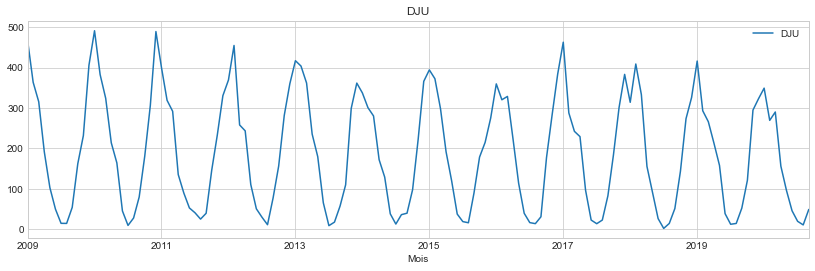

In [14]:
df_dju_21.plot(y="DJU", figsize=(14,4))
plt.title("DJU")
plt.savefig('DJU')
print('')

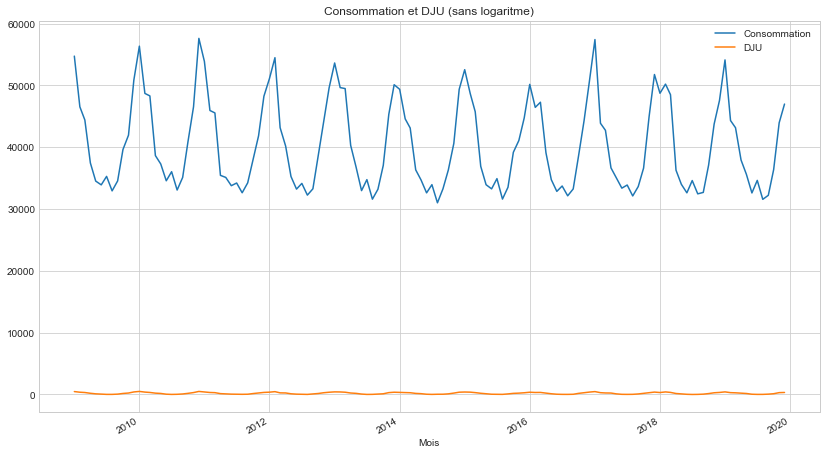

In [15]:
df_conso.plot(figsize=(14,8))
plt.title("Consommation et DJU (sans logaritme)")
print('')
plt.savefig('Consommation et DJU (sans logaritme)')

Nous observons une forte corrélation:


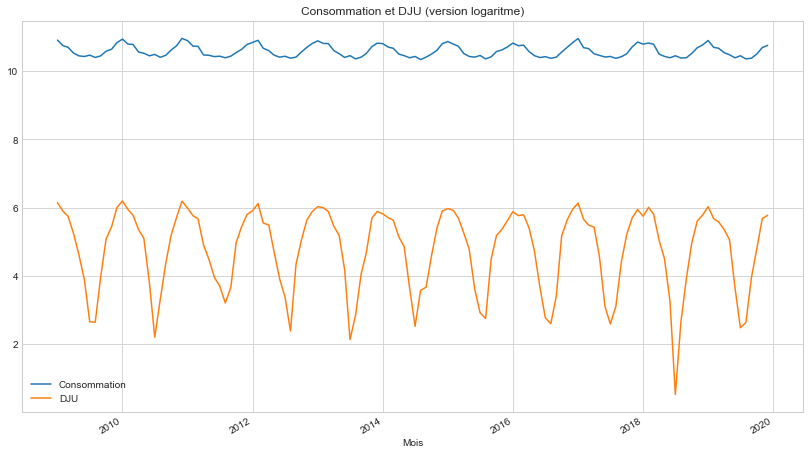

In [16]:
np.log(df_conso).plot(figsize=(14,8))
print('Nous observons une forte corrélation:')
plt.title("Consommation et DJU (version logaritme)")
plt.savefig('Consommation et DJU (avec logaritme)')


## Désaisonnalisation à l'aide de la régression linéaire

### Création des bases tendancielle et saisonnière

Stockage de la série temporelle Consommation d'énergie sous la variable y, et le DJU sous la variable x:

In [17]:
y = df_conso['Consommation']
x = sm.add_constant(df_conso['DJU'])
# It doesn't add a constant to your values, it adds a constant term to the linear equation it is fitting. In the single-predictor case, it's the difference between fitting an a line y = mx to your data vs fitting y = mx + b.
# As you can see, a column of ones is added to SAT. This column of ones corresponds to x_0 in the simple linear regression equation: y_hat = b_0 * x_0 + b_1 * x_1. As explained in the lecture video, x_0 is always one and thus the regression equation becomes: y_hat = b_0 * 1 + b_1 * x_1. The x array holds 1 and x_1.
linReg = sm.OLS(y, x).fit()
print(linReg.summary())
linReg.summary()

                            OLS Regression Results                            
Dep. Variable:           Consommation   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     2049.
Date:                Wed, 18 May 2022   Prob (F-statistic):           1.87e-81
Time:                        16:57:14   Log-Likelihood:                -1172.9
No. Observations:                 132   AIC:                             2350.
Df Residuals:                     130   BIC:                             2356.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        3.09e+04    258.365    119.594      0.0

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Consommation   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     2049.
Date:                Wed, 18 May 2022   Prob (F-statistic):           1.87e-81
Time:                        16:57:14   Log-Likelihood:                -1172.9
No. Observations:                 132   AIC:                             2350.
Df Residuals:                     130   BIC:                             2356.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        3.09e+04    258.365    119.594      0.000    3.04e+04    3.14e+04
DJU           49.1169      1.085     45.270      0.000      46.970      51.263
==============================================================================
Omnibus:                        0.570   Durbin-Watson:                   2.100
Prob(Omnibus):                  0.752   Jarque-Bera (JB):                0.232
Skew:                          -0.025   Prob(JB):                        0.891
Kurtosis:                       3.199   Cond. No.                         401.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
print("Coefficient = ", round(linReg.params['DJU'], 2))
print("\nR2:", round(linReg.rsquared, 2))

Coefficient =  49.12

R2: 0.94


Nous obtenons des statistiques sur le coefficient obtenu : valeur, écart-type, statistique de test de Student, et la p-valeur (le test effectué est ici le test de significativité : le paramètre vaut 0 versus le paramètre est différent de 0), ainsi que des statistiques sur le modèle général ($R^{2}$, $AIC$, etc...).

*Les p-valeurs sont inférieures à 5 %. À un niveau de test de 5 %, on rejette donc l'hypothèse selon laquelle le paramètre est proche de 0 : les paramètres sont donc significativement différents de 0.
Ici, on voit que DJU est significatif.*

Quant au $R^{2}$, il est de l'ordre de $0.94$. Ce qui est élevé.

### Diagnostic de la régression - Normalité des résidus

Répartition des résidus proche de la normalité:


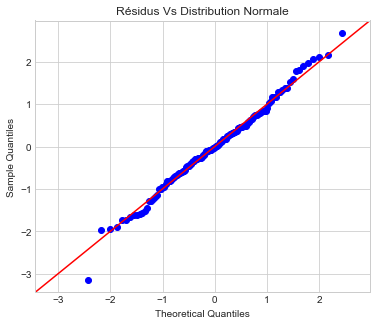

In [19]:
fig = sm.qqplot(linReg.resid, fit=True, line="45")
print('Répartition des résidus proche de la normalité:')
fig.set_figheight(5)
fig.set_figwidth(6)
plt.title("Résidus Vs Distribution Normale")
#leg = plt.legend(loc='center left')
plt.savefig('Residus Vs Distribution Normale')
plt.show()

Répartition des résidus proche de la normalité:


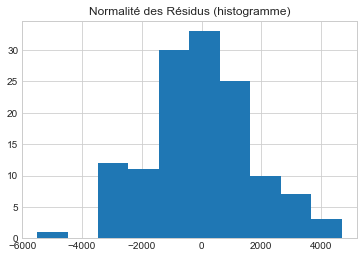

In [20]:
linReg.resid.hist()
plt.title("Normalité des Résidus (histogramme)")
plt.savefig('Normalité des Résidus Regression Linéaire (histogramme)')
print('Répartition des résidus proche de la normalité:')

Testons la normalité des résidus avec un test de Shapiro-Wilk 

L'hypothèse nulle est que la population est normalement distribuée.

In [21]:
print(shapiro(linReg.resid))

print("\nL'hypothèese de la normalité des résidus ne peut être rejetée")

ShapiroResult(statistic=0.993927001953125, pvalue=0.8479569554328918)

L'hypothèese de la normalité des résidus ne peut être rejetée


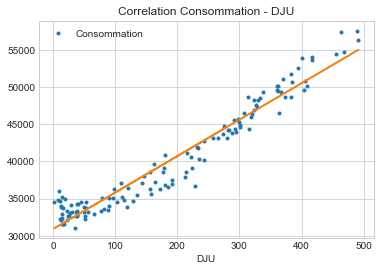

In [22]:
df_conso.plot(x = 'DJU', y = 'Consommation', style='.')
plt.plot(df_conso['DJU'], linReg.predict(sm.add_constant(df_conso['DJU'])))
plt.title("Correlation Consommation - DJU")
plt.savefig('Correlation Consommation - DJU')
print('')

L’inférence dans la régression linéaire multiple (MCO) repose sur l’hypothèse de normalité
des erreurs. Une première vérification importante consiste à vérifier la compatibilité des
résidus (l’erreur observée sur l’échantillon) avec ce présupposé.

Test de Jarque-Bera.
  H0: les données suivent une loi normale.

In [23]:
JB, JBpv,skw,kurt = sm.stats.stattools.jarque_bera(linReg.resid)
#print(JB,JBpv,skw,kurt)
print("\nLa valeur JB =", JB, "==> nous ne rejetons pas l'hypothese null: les résidus de la régression linéaire suivent une distribution normale. ")


La valeur JB = 0.23169003078237466 ==> nous ne rejetons pas l'hypothese null: les résidus de la régression linéaire suivent une distribution normale. 


### Correction de la consommation d'energie

In [24]:
df_conso

,Consommation,DJU
Mois,,
2014-03-01,43104.0,280.3
2014-06-01,32609.0,37.8
2014-10-01,36301.0,97.6
2014-11-01,40617.0,222.7
2013-02-01,49639.0,403.9
...,...,...
2019-01-01,54117.0,416.3
2019-03-01,43146.0,266.0
2019-09-01,32214.0,52.0


In [25]:
#  conso corrigée de l'effet température (CCET) = conso totale - DJUtotal * alpha 
df_conso["Conso_correction"] = df_conso["Consommation"] - df_conso["DJU"] * linReg.params['DJU']
df_conso.sort_index(inplace=True)
df_conso

,Consommation,DJU,Conso_correction
Mois,,,
2009-01-01,54730.0,468.0,31743.275510
2009-02-01,46530.0,363.7,28666.171588
2009-03-01,44401.0,315.4,28909.519436
2009-04-01,37449.0,191.2,28057.842473
2009-05-01,34516.0,102.6,29476.602708
...,...,...,...
2019-08-01,31564.0,14.0,30876.362943
2019-09-01,32214.0,52.0,29659.919501
2019-10-01,36367.0,120.9,30428.762840


In [26]:
df_conso_corr = df_conso[['Conso_correction','Consommation']]

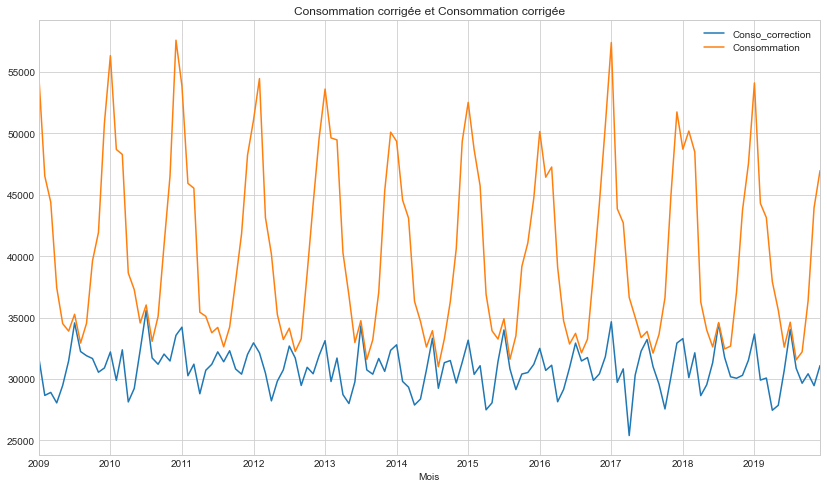

In [27]:
df_conso_corr.plot(figsize=(14,8))
plt.title("Consommation corrigée et Consommation corrigée")
plt.savefig('Consommation et Consommation corrigée')
print('')

# Désaisonnalisation de la consommation

## Moyenne mobile

In [28]:
df_conso_corr_2 = df_conso_corr[["Conso_correction"]]
df_conso_corr_2

,Conso_correction
Mois,
2009-01-01,31743.275510
2009-02-01,28666.171588
2009-03-01,28909.519436
2009-04-01,28057.842473
2009-05-01,29476.602708
...,...
2019-08-01,30876.362943
2019-09-01,29659.919501
2019-10-01,30428.762840


The terms can also refer to a particular model for time series data, where the model can be decomposed into four different components:

related in an additive sense:  

yt = Tt + St + Ct + Rt

related by multiplication:

yt = Tt * St * Ct * Rt

Their advantage is that they are more flexible than linear models, but keep many of the desirable properties of their linear counterparts

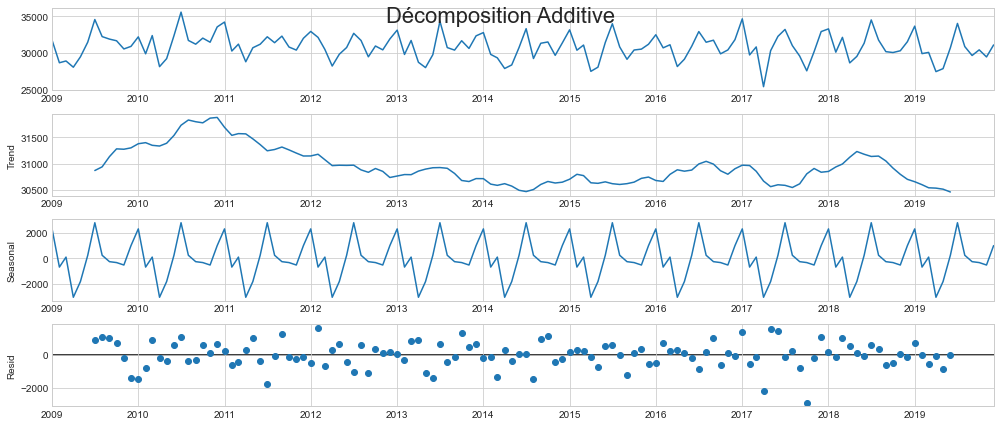

In [29]:
plt.rcParams.update({'figure.figsize': (14,6)})

decomp_x = seasonal_decompose(df_conso_corr_2,  model='additive')
decomp_x.plot().suptitle('Décomposition Additive', fontsize=22)

plt.savefig('Decomposition_Additive')
plt.show()

Nous n'observons pas de tendance clair mais nous observons une saisonalité.


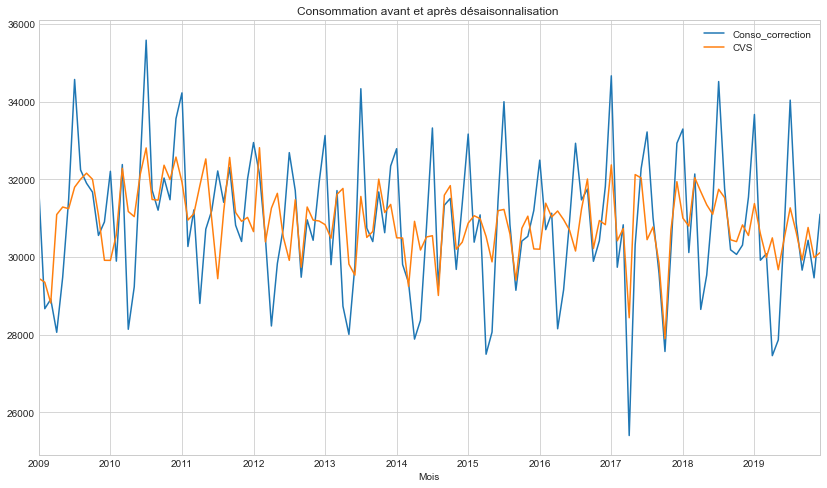

In [30]:
#Différence avec la saisonnalité 
df_conso_corr_2['CVS'] = df_conso_corr_2['Conso_correction'] - decomp_x.seasonal

df_conso_corr_2.plot(figsize=(14,8))
plt.title("Consommation avant et après désaisonnalisation ")
plt.savefig('CVS_Consommation avant et après désaisonnalisation')
print('')

# Prévision de la consommation (corrigée de l'effet température)

## Méthode de Holt Winters (lissage exponentiel)

La méthode de Holt Winters est un moyen de modéliser trois aspects de la série chronologique : une valeur typique (moyenne), une tendance dans le temps et une répétition cyclique (saisonnalité). Elle utilise le lissage exponentiel pour coder de nombreuses valeurs du passé et les utiliser pour prédire des valeurs « typiques » pour le présent et le futur. Le lissage exponentiel fait référence à l'utilisation d'une moyenne mobile à pondération exponentielle (EWMA) pour «lisser» une série chronologique.

Les paramètres de la méthode de Holt-Winters sont α , β  et γ  (tous dans ]0,1[ ).
La prévision par la méthode de Holt-Winters est la suivante :

XˆT(ℓ)=aˆT+ℓbˆT+SˆT+ℓ−s    	si ℓ∈{1,…,s}

XˆT(ℓ)=aˆT+ℓbˆT+SˆT+ℓ−2s 	si ℓ∈{s+1,…,2s} 

In [31]:
df_conso_corr_3 = df_conso_corr_2[["Conso_correction"]]
df_conso_corr_3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 132 entries, 2009-01-01 to 2019-12-01
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Conso_correction  132 non-null    float64
dtypes: float64(1)
memory usage: 2.1 KB


Nouveau dataframe avec l'année à prédire (2019) supprimée pour comparaison:

In [32]:
#df_conso_corr_31 = df_conso_corr_3.loc[df_conso_corr_3.index<datetime.strptime('2018-10-01', '%Y-%m-%d'),:]
df_conso_corr_31 = df_conso_corr_3.loc[df_conso_corr_3.index<datetime.strptime('2019-01-01', '%Y-%m-%d'),:]

Consommation d'énergie corrigée originale:

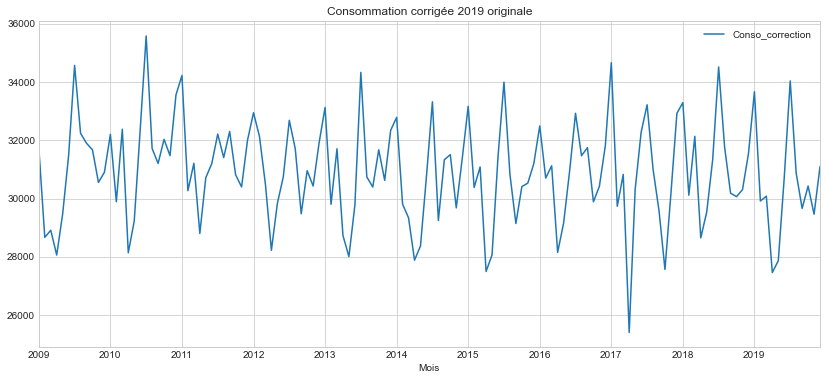

In [33]:
df_conso_corr_3.plot()
plt.title("Consommation corrigée 2019 originale")
plt.savefig('Consommation corrigée 2019 originale')

#  conso corrigée de l'effet température (CCET) = conso totale - alpha * DJUtotal  
# CVS = CCET - la composante saisonnière de CCET obtenue avec seasonal decompose

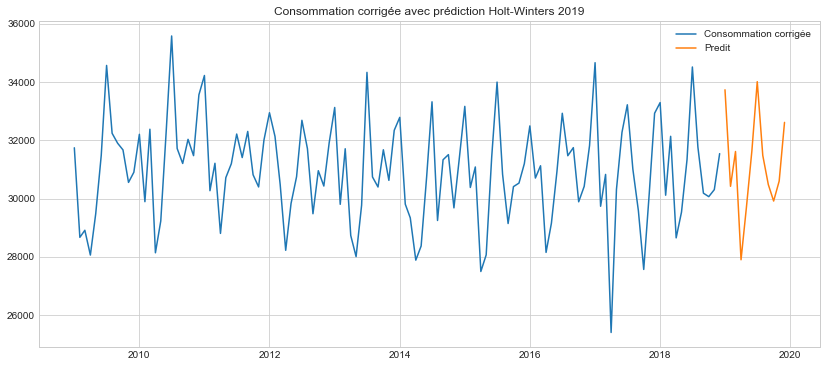

In [34]:
# modele additif
hw = ExponentialSmoothing(np.asarray(df_conso_corr_31['Conso_correction']), seasonal_periods=12, trend='add', seasonal='add').fit()
hw_pred = hw.forecast(12)

plt.figure(figsize=(14,6))

plt.plot(df_conso_corr_31['Conso_correction'], label='Consommation corrigée')
plt.plot(pd.date_range(df_conso_corr_31.index[len(df_conso_corr_31)-1], periods=12, freq='M'), hw_pred, label='Predit')
plt.legend()
plt.title("Consommation corrigée avec prédiction Holt-Winters 2019")
plt.savefig('Consommation corrigée avec prédiction Holt-Winters 2019')
plt.show()

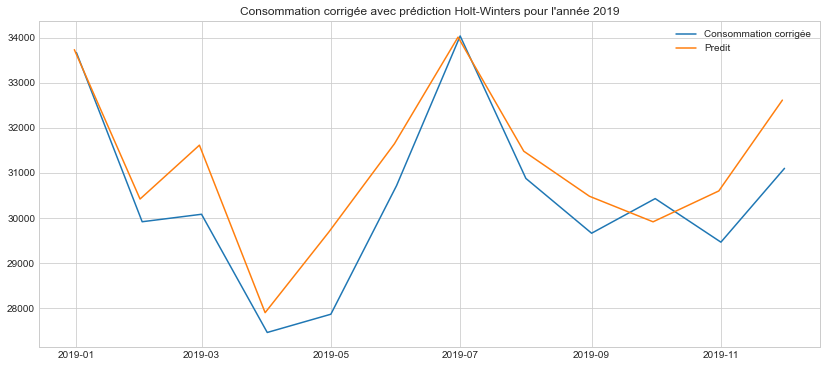

In [35]:
# modele additif
hw = ExponentialSmoothing(np.asarray(df_conso_corr_31['Conso_correction']), seasonal_periods=12, trend='add', seasonal='add').fit()
hw_pred = hw.forecast(12)

plt.figure(figsize=(14,6))

plt.plot(df_conso_corr_3['Conso_correction'].iloc[-12:], label='Consommation corrigée')
plt.plot(pd.date_range(df_conso_corr_31.index[len(df_conso_corr_31)-1], periods=12, freq='M'), hw_pred, label='Predit')
plt.legend()
plt.title("Consommation corrigée avec prédiction Holt-Winters pour l'année 2019")
plt.savefig("Consommation corrigée avec prédiction Holt-Winters pour l'année 2019")
plt.show()

In [36]:
df_conso_corr_2

,Conso_correction,CVS
Mois,,
2009-01-01,31743.275510,29448.324791
2009-02-01,28666.171588,29347.376739
2009-03-01,28909.519436,28812.574030
2009-04-01,28057.842473,31092.358189
2009-05-01,29476.602708,31285.749613
...,...,...
2019-08-01,30876.362943,30637.853127
2019-09-01,29659.919501,29919.096708
2019-10-01,30428.762840,30758.732636


## Méthode  SARIMA sur la série temporelle

Les modèles SARIMA permettent de modéliser des séries qui présentent une saisonnalité.

Estimer un modèle SARIMA se ramène en pratique à l'estimation d'un modèle ARMA sur la série différenciée.
Etapes:

1_ stationnarisation (éventuellement),

2_ identification a priori de modèles potentiels,

3_ estimation des modèles potentiels,

4_ vérification des modèles potentiels,

5_ choix définitif d'un modèle,

6_ prévision à l'aide du modèle choisi,

7_ analyse a posteriori de la prévision.

### Stationnarisation de la série

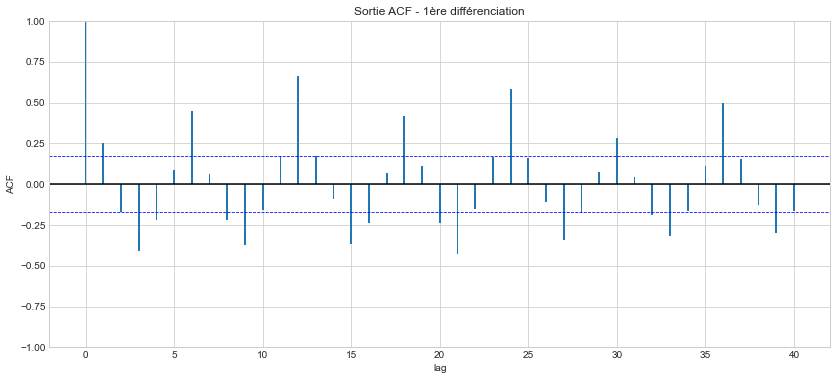

In [37]:
y_len = len(df_conso_corr_3['Conso_correction']) # variable nécessaire pour l'utilisation de plot_sortie_acf

plt.figure(figsize=(14,6))
plt.bar(range(len(acf(np.asarray(df_conso_corr_3['Conso_correction'])))), acf(np.asarray(df_conso_corr_3['Conso_correction'])), width = 0.1)
plt.xlabel('lag')
plt.ylabel('ACF')
plt.axhline(y=0, color='black')
plt.axhline(y=-1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.axhline(y=1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.ylim(-1, 1)

plt.title('Sortie ACF - 1ère différenciation')
plt.savefig("Sortie_ACF_1ere_differenciation")

plt.show()

La sortie ACF présente une décroissance lente vers 0, ce qui traduit un problème de non-stationnarité. On effectue donc une différenciation $(I−B)$ .

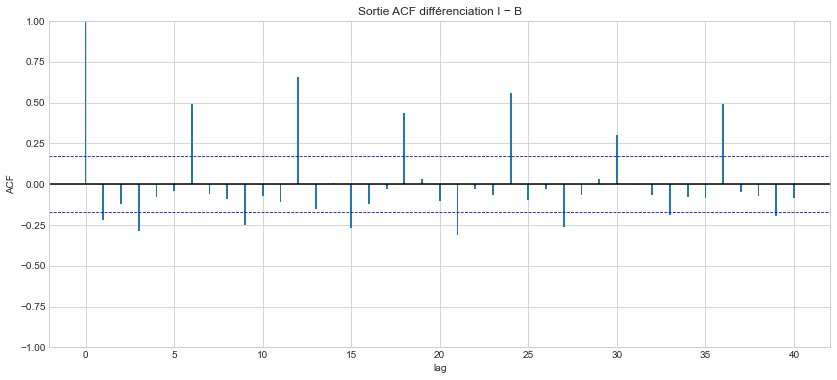

In [38]:
y_dif1 = df_conso_corr_3['Conso_correction'] - df_conso_corr_3['Conso_correction'].shift(1)

#plot_sortie_acf(acf(np.asarray(y_dif1[1:])), y_len)

plt.figure(figsize=(14,6))
plt.bar(range(len(acf(np.asarray(y_dif1[1:])))), acf(np.asarray(y_dif1[1:])), width = 0.1)
plt.xlabel('lag')
plt.ylabel('ACF')
plt.axhline(y=0, color='black')
plt.axhline(y=-1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.axhline(y=1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.ylim(-1, 1)

plt.title('Sortie ACF différenciation I − B')
plt.savefig("Sortie_ACF_differenciation_𝐼_𝐵")


La sortie ACF de la série ainsi différenciée présente encore une décroissance lente vers 0 pour les multiples de 12. On effectue cette fois la différenciation $(I−B^{12})$ .

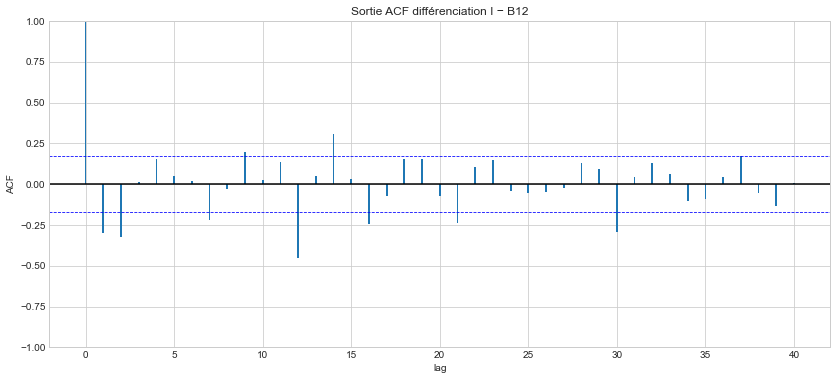

In [39]:
y_dif_1_12 = y_dif1 - y_dif1.shift(12)



plt.figure(figsize=(14,6))
plt.bar(range(len(acf(np.asarray(y_dif_1_12[13:])))), acf(np.asarray(y_dif_1_12[13:])), width = 0.1)
plt.xlabel('lag')
plt.ylabel('ACF')
plt.axhline(y=0, color='black')
plt.axhline(y=-1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.axhline(y=1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.ylim(-1, 1)

plt.title('Sortie ACF différenciation I − B12')
plt.savefig("Sortie_ACF_differenciation_𝐼_𝐵12")


In [40]:
# Augmented Dickey-Fuller test

X = np.asarray(y_dif_1_12[13:])
result = adfuller(X)
print('Dickey-Fuller Statistic: %f' % result[0])
print('p-value: %f' % result[1])
    
#H0: The time series is non-stationary. In other words, it has some time-dependent structure and does not have constant variance over time.
#HA: The time series is stationary.
# Since the p-value is not less than .05, we fail to reject the null hypothesis.
# This means the time series is non-stationary. In other words, it has some time-dependent structure and does not have constant variance over time.
#print('Nous rejetons H0 et concluons que la série est stationnaire')


Dickey-Fuller Statistic: -4.732767
p-value: 0.000073


Nous rejetons H0 et concluons que la série est stationnaire

### Identification, estimation et validation de modèles

On s’appuie sur les autocorrélogrammes simple et partiels estimés :

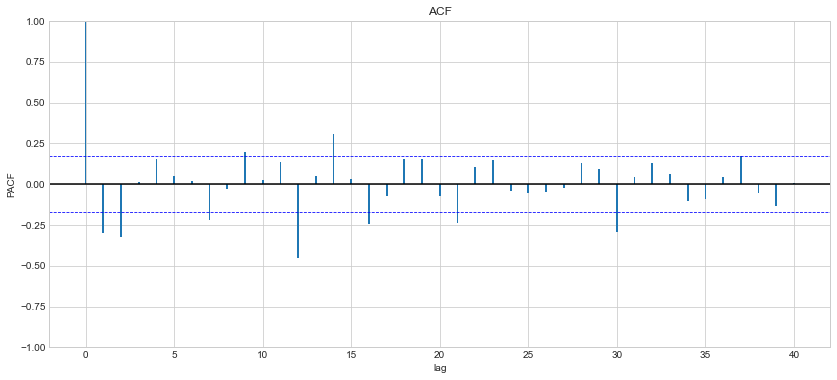

In [41]:
y_dif_1_12 = y_dif1 - y_dif1.shift(12)

plt.figure(figsize=(14,6))
plt.bar(range(len(acf(np.asarray(y_dif_1_12[13:])))), acf(np.asarray(y_dif_1_12[13:])), width = 0.1)
plt.xlabel('lag')
plt.ylabel('PACF')
plt.axhline(y=0, color='black')
plt.axhline(y=-1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.axhline(y=1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.ylim(-1, 1)

plt.title('ACF')
plt.savefig("ACF")

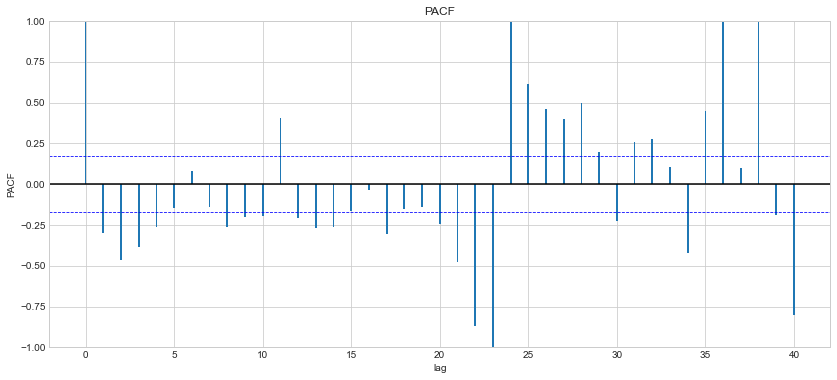

In [42]:
#plot_sortie_acf(pacf(np.asarray(y_dif_1_12[13:])), y_len, pacf=True)

plt.figure(figsize=(14,6))
plt.bar(range(len(pacf(np.asarray(y_dif_1_12[13:])))), pacf(np.asarray(y_dif_1_12[13:])), width = 0.1)
plt.xlabel('lag')
plt.ylabel('PACF')
plt.axhline(y=0, color='black')
plt.axhline(y=-1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.axhline(y=1.96/np.sqrt(y_len), color='b', linestyle='--', linewidth=0.8)
plt.ylim(-1, 1)

plt.title('PACF')
plt.savefig("PACF")

#### Modèle 1

On estime en premier lieu un modèle  𝑆𝐴𝑅𝐼𝑀𝐴(1,1,1)(1,1,1)12

In [43]:
model1 = SARIMAX(np.asarray(df_conso_corr_31['Conso_correction']), order=(1,1,1), seasonal_order=(1,1,1,12))
results1 = model1.fit()
print(results1.summary())

print('Retard : p-value')
for elt in [6, 12, 18, 24, 30, 36]:
    print('{} : {}'.format(elt, acorr_ljungbox(results1.resid, lags=elt)[1].mean()))

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -931.018
Date:                            Wed, 18 May 2022   AIC                           1872.037
Time:                                    16:57:18   BIC                           1885.401
Sample:                                         0   HQIC                          1877.455
                                            - 120                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2654      0.163      1.628      0.104      -0.054       0.585
ma.L1         -0.4941      0.154   

Ce modèle ayant des paramètres non significatifs, on en teste un second.

#### Modèle 2

Soit le modèle :
$$ (I−B)(I−B^{12})ln(X_{t})=(I+θ_{1}B)(I+θ′_{1}B^{12})ε_{t}$$

In [44]:
model2 = SARIMAX(np.asarray(df_conso_corr_31['Conso_correction']), order=(0,1,1), seasonal_order=(1,1,1,12))
results2 = model2.fit()
print(results2.summary())

print('Retard : p-value')
for elt in [6, 12, 18, 24, 30, 36]:
    print('{} : {}'.format(elt, acorr_ljungbox(results2.resid, lags=elt)[1].mean()))

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  120
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -932.325
Date:                            Wed, 18 May 2022   AIC                           1872.649
Time:                                    16:57:18   BIC                           1883.340
Sample:                                         0   HQIC                          1876.983
                                            - 120                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2392      0.037     -6.517      0.000      -0.311      -0.167
ar.S.L12       0.4128      0.104   

Les tests de significativité des paramètres et de blancheur du résidu sont validés au niveau 5%.

In [45]:
shapiro(results2.resid)

ShapiroResult(statistic=0.47564542293548584, pvalue=7.823213671633582e-19)

Le test de normalité est également validé pour ce modèle.

### Prévision à l’aide du modèle retenu (2) de l’année 2019

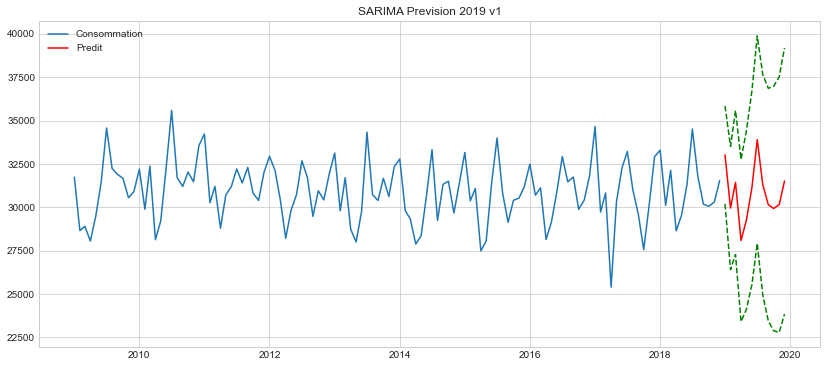

<Figure size 1008x432 with 0 Axes>

In [46]:
import numpy as np

pred_model2 = results2.get_forecast(12)
#pred = np.exp(pred_model2.predicted_mean)

pred = pred_model2.predicted_mean
pred_l = [elt[0] for elt in pred_model2.conf_int(alpha=0.05)]
pred_u = [elt[1] for elt in pred_model2.conf_int(alpha=0.05)]

plt.figure(figsize=(14,6))
plt.title('SARIMA Prevision 2019 v1')
plt.plot(df_conso_corr_31['Conso_correction'], label='Consommation')
plt.plot(pd.date_range(df_conso_corr_31.index[len(df_conso_corr_31)-1], periods=12, freq='M'), pred, color='r', label='Predit')
plt.plot(pd.date_range(df_conso_corr_31.index[len(df_conso_corr_31)-1], periods=12, freq='M'), pred_l, color='g', linestyle='--')
plt.plot(pd.date_range(df_conso_corr_31.index[len(df_conso_corr_31)-1], periods=12, freq='M'), pred_u, color='g', linestyle='--')
plt.legend()
plt.show()

plt.savefig("SARIMA_Prevision_2019_v1")

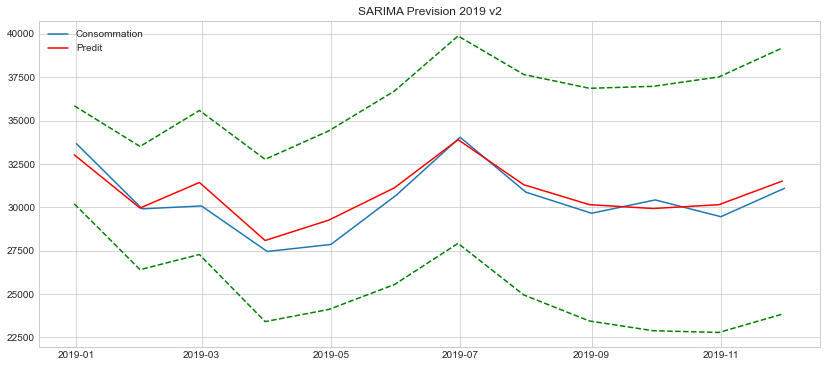

In [47]:
plt.figure(figsize=(14,6))
plt.plot(df_conso_corr_3['Conso_correction']['2019':], label='Consommation')
plt.plot(pd.date_range(df_conso_corr_31.index[len(df_conso_corr_31)-1], periods=12, freq='M'), pred, color='r', label='Predit')
plt.plot(pd.date_range(df_conso_corr_31.index[len(df_conso_corr_31)-1], periods=12, freq='M'), pred_l, color='g', linestyle='--')
plt.plot(pd.date_range(df_conso_corr_31.index[len(df_conso_corr_31)-1], periods=12, freq='M'), pred_u, color='g', linestyle='--')
plt.legend()
plt.title('SARIMA Prevision 2019 v2')
plt.savefig("SARIMA_Prevision_2019_v2")
plt.show()

### Analyse a posteriori

On tronque la série de l’année 2019, qu’on cherche ensuite à prévoir à partir de l’historique.

In [48]:
# L'analyse a posteriori permet de quantifier les écarts entre les prévisions et les réalisations, en tronquant la série d'un certain nombre de points (notons que le modèle doit être correctement estimé sur la série tronquée.

x_tronc = df_conso_corr_31['Conso_correction'] #df_conso_corr_3[:'2018']
y_tronc = np.log(x_tronc)
#x_a_prevoir = df_conso_corr_3['Conso_correction']['2019':]
x_a_prevoir = df_conso_corr_3[df_conso_corr_3.index.year == 2019]

# .month == 12   boulder_precip_2003_2013[boulder_precip_2003_2013.index.month == 12].tail()

On vérifie que le modèle 2 sur la série tronquée est toujours validé.

In [49]:
#model2tronc = SARIMAX(np.asarray(y_tronc['Conso_correction']), order=(0,1,1), seasonal_order=(1,1,1,12))
model2tronc = SARIMAX(np.asarray(y_tronc), order=(0,1,1), seasonal_order=(1,1,1,12))

results2tronc = model2tronc.fit()
print(results2tronc.summary())

print('Retard : p-value')
for elt in [6, 12, 18, 24, 30, 36]:
    print('{} : {}'.format(elt, acorr_ljungbox(results2tronc.resid, lags=elt)[1].mean()))
    
shapiro(results2tronc.resid)



# df_conso_corr_31


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  120
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 205.243
Date:                            Wed, 18 May 2022   AIC                           -402.487
Time:                                    16:57:19   BIC                           -391.795
Sample:                                         0   HQIC                          -398.153
                                            - 120                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8990      0.064    -13.969      0.000      -1.025      -0.773
ar.S.L12      -0.0751      0.175   

ShapiroResult(statistic=0.14010292291641235, pvalue=2.2292546538385408e-23)

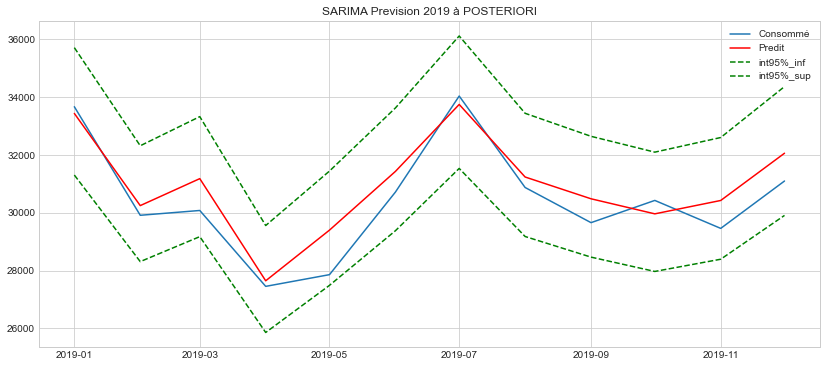

In [50]:
pred_model2tronc = results2tronc.get_forecast(12)
pred_tronc = np.exp(pred_model2tronc.predicted_mean)
pred_l_tronc = [np.exp(elt[0]) for elt in pred_model2tronc.conf_int(alpha=0.05)]
pred_u_tronc = [np.exp(elt[1]) for elt in pred_model2tronc.conf_int(alpha=0.05)]

plt.figure(figsize=(14,6))
plt.plot(x_a_prevoir, label='Consommé')
plt.plot(x_a_prevoir.index, pred_tronc, color='r', label='Predit')
plt.plot(x_a_prevoir.index, pred_l_tronc, color='g', linestyle='--', label='int95%_inf')
plt.plot(x_a_prevoir.index, pred_u_tronc, color='g', linestyle='--', label='int95%_sup')
plt.legend()
plt.title('SARIMA Prevision 2019 à POSTERIORI')
plt.savefig("SARIMA_Prevision_2019_APOSTERIORI")
plt.show()

On calcule les RMSE et MAPE.

In [51]:
rmse = np.sqrt(((x_a_prevoir['Conso_correction']-pred_tronc)**2).mean())
print('RMSE = ',rmse)

# Un dernier indicateur pertinent est le RMSE. Cet indice fournit une indication par rapport à la dispersion ou la variabilité de la qualité de la prédiction. 
# Par exemple, un RMSE de 10 est relativement faible si la moyenne des observations est de 500. Pourtant, un modèle a une variance forte s’il conduit à un RMSE de 10 alors que la moyenne des observations est de 15. 
#En effet, dans le premier cas, la variance du modèle correspond à seulement 5% de la moyenne des observations alors que dans le second cas, la variance atteint plus de 65% de la moyenne des observations.

RMSE =  778.3415647820133


In [52]:
mape=(np.abs(1-pred_tronc/x_a_prevoir['Conso_correction'])).mean()*100
print('MAPE = ', mape)

# The Mean Absolute Percentage Error (MAPE) is one of the most commonly used KPIs to measure forecast accuracy.
# MAPE is the sum of the individual absolute errors divided by the demand (each period separately). It is the average of the percentage errors.


MAPE =  2.227939817416365


*MAPE = 2.22* < 10  Ceci indique une trés bonne prédiction







Fin